# 06 · Probability Calibration & Cost-Based Threshold Optimisation

**Owner:** Riya (Model Lead) — with Praveen (the dashboard's cost slider uses the same formulas)

**Business costs.** $C_{offer}$ = ₹1,500 per retention offer · $C_{lost}$ = ₹15,000 per churner who leaves undetected.

$$\text{TotalCost}(\tau) = FN(\tau)\cdot C_{lost} + \big(TP(\tau) + FP(\tau)\big)\cdot C_{offer}$$

(assumption: an offer always retains a true churner). We sweep τ = 0.01 … 0.99 on the **validation** set and pick τ* = argmin TotalCost.

**Theory check.** For one customer with *calibrated* churn probability p: sending an offer costs $C_{offer}$; not sending costs $p\,C_{lost}$ in expectation. Send iff $p > C_{offer}/C_{lost} = 1{,}500/15{,}000 = \mathbf{0.10}$. The empirical τ* should land near 0.10 — **if the probabilities are calibrated**. That is why we calibrate first.

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

In [3]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src import config
from src import plotting as P
from src.calibration import PlattCalibrator, reliability_summary
from src.cost_optimizer import (CostParams, baseline_costs, expected_cost_unlabeled, find_optimal_threshold,
                                format_currency, savings_summary, save_sweep, sweep_thresholds,
                                write_recommendation)
from src.data_preprocessing import load_splits
from src.metrics import classification_metrics, find_f1_optimal_threshold
from src.model import load_model, predict_logits

P.apply_style()
device = config.get_device()
splits = load_splits()                               # validation only — test stays hidden
X_val, y_val = splits.X_val, splits.y_val
cfg = config.load_model_config()
if 'imbalance_strategy' not in cfg:
    raise RuntimeError('Run notebook 05 first: model_config.json has no imbalance_strategy yet.')
strategy = cfg['imbalance_strategy']['label']
model = load_model(config.BEST_MODEL_PATH, X_val.shape[1], cfg['architecture'], device)
print('Deployed model:', strategy)

Deployed model: 2. Weighted BCE


## 1 · Platt calibration
Weighted BCE multiplies the loss of every churner by ≈2.77, so the network learns inflated probabilities (notebook 05: mean predicted p ≈ 0.43 vs a true churn rate of 0.265). The *ranking* is still good, but "p = 0.7" would not mean a 70 % chance. Platt scaling fits $p_{cal} = \sigma(a z + b)$ on the validation logits z — two parameters, monotonic, so PR-AUC/ROC-AUC are unchanged.

Platt parameters: a = 1.0121, b = -1.0878
Observed churn rate            : 0.2654
Mean predicted p (raw)         : 0.4322   Brier 0.1751
Mean predicted p (calibrated)  : 0.2654   Brier 0.1390
PR-AUC raw 0.6353 == calibrated 0.6353  (monotonic transform -> ranking unchanged)


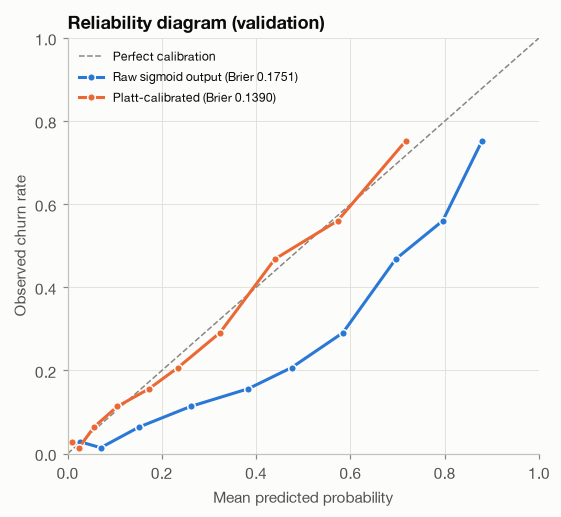

In [4]:
val_logits = predict_logits(model, X_val, device=device)
raw_prob = 1 / (1 + np.exp(-val_logits))
calibrator = PlattCalibrator().fit(val_logits, y_val)
cal_prob = calibrator.transform(val_logits)

rel_raw, rel_cal = reliability_summary(y_val, raw_prob), reliability_summary(y_val, cal_prob)
print(f'Platt parameters: a = {calibrator.a:.4f}, b = {calibrator.b:.4f}')
print(f'Observed churn rate            : {y_val.mean():.4f}')
print(f'Mean predicted p (raw)         : {rel_raw["mean_predicted"]:.4f}   Brier {rel_raw["brier"]:.4f}')
print(f'Mean predicted p (calibrated)  : {rel_cal["mean_predicted"]:.4f}   Brier {rel_cal["brier"]:.4f}')

auc_raw = classification_metrics(y_val, raw_prob)['pr_auc']
auc_cal = classification_metrics(y_val, cal_prob)['pr_auc']
assert abs(auc_raw - auc_cal) < 1e-9, 'calibration must not change the ranking'
print(f'PR-AUC raw {auc_raw:.4f} == calibrated {auc_cal:.4f}  (monotonic transform -> ranking unchanged)')

fig = P.plot_reliability({'Raw sigmoid output': rel_raw, 'Platt-calibrated': rel_cal})
P.save_figure(fig, config.PLOTS_DIR / 'calibration_reliability.png')
plt.show()

## 2 · Threshold sweep on the validation set

τ* = 0.08   (theory C_offer/C_lost = 0.10)
Minimum total cost      : ₹16,87,500  (975 customers flagged, 359 churners caught, 15 missed)
Do nothing              : ₹56,10,000
Target everyone         : ₹21,13,500


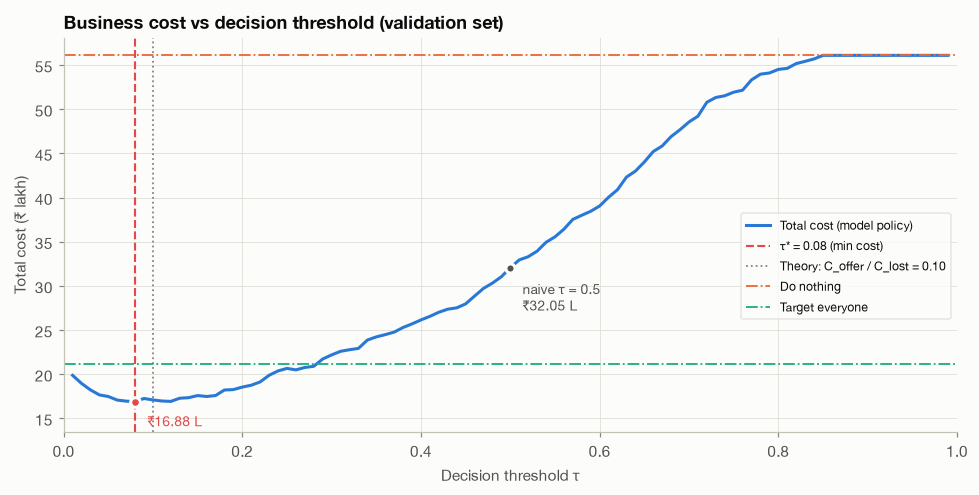

In [5]:
params = CostParams(c_offer=config.C_OFFER, c_lost=config.C_LOST, currency=config.CURRENCY_SYMBOL)
sweep = sweep_thresholds(y_val, cal_prob, params)          # τ = 0.01, 0.02, ..., 0.99
best = find_optimal_threshold(sweep)
tau_star = float(best['threshold'])
baselines = baseline_costs(y_val, params)
save_sweep(sweep, config.RESULTS_DIR / 'cost_sweep_val.csv')

print(f'τ* = {tau_star:.2f}   (theory C_offer/C_lost = {params.breakeven_probability:.2f})')
print(f'Minimum total cost      : {format_currency(best["total_cost"])}  '
      f'({int(best["n_flagged"])} customers flagged, {int(best["tp"])} churners caught, {int(best["fn"])} missed)')
print(f'Do nothing              : {format_currency(baselines["do_nothing"])}')
print(f'Target everyone         : {format_currency(baselines["target_everyone"])}')

fig = P.plot_cost_curve(sweep, tau_star, float(best['total_cost']), currency='₹', naive_threshold=0.5,
                        breakeven=params.breakeven_probability, baselines=baselines)
P.save_figure(fig, config.PLOTS_DIR / 'cost_vs_threshold.png')
plt.show()

In [6]:
show = sorted({0.05, 0.10, tau_star, 0.20, 0.30, 0.40, 0.50, 0.70})
table = sweep.set_index('threshold').loc[show, ['n_flagged', 'tp', 'fp', 'fn', 'precision', 'recall', 'total_cost']]
table['total_cost'] = table['total_cost'].map(format_currency)
table.round(3)

,n_flagged,tp,fp,fn,precision,recall,total_cost
threshold,,,,,,,
0.05,1075,365,710,9,0.340,0.976,"₹17,47,500"
0.08,975,359,616,15,0.368,0.960,"₹16,87,500"
0.10,929,353,576,21,0.380,0.944,"₹17,08,500"
0.20,706,321,385,53,0.455,0.858,"₹18,54,000"
0.30,519,278,241,96,0.536,0.743,"₹22,18,500"
0.40,393,239,154,135,0.608,0.639,"₹26,14,500"
0.50,287,189,98,185,0.659,0.505,"₹32,05,500"
0.70,77,58,19,316,0.753,0.155,"₹48,55,500"


## 3 · Written recommendation
Generated from the numbers above (so it stays correct if the notebook is re-run):

In [7]:
opt_summary = savings_summary(y_val, cal_prob, tau_star, params)
naive_summary = savings_summary(y_val, cal_prob, 0.5, params)
recommendation = write_recommendation(opt_summary, naive_summary, params, split_name='validation')
(config.RESULTS_DIR / 'threshold_recommendation.md').write_text(recommendation + '\n', encoding='utf-8')
config.save_json({'optimal': opt_summary, 'naive_0.5': naive_summary}, config.RESULTS_DIR / 'cost_summary_val.json')
display(Markdown('> ' + recommendation))

> We recommend a decision threshold of τ* = 0.08: every customer whose calibrated churn probability is at least 8% receives a retention offer. On the validation set (1,409 customers) this flags 975 customers (69.2%), catching 359 of 374 churners, for an expected total cost of ₹16,87,500. Doing nothing would cost ₹56,10,000, so the policy saves ₹39,22,500 (69.9%); targeting everyone would cost ₹21,13,500, so it also saves ₹4,26,000 (20.2%) against that policy. The naive 0.5 threshold would flag only 287 customers and cost ₹32,05,500 — ₹15,18,000 more — because each missed churner (₹15,000) costs 10× an offer (₹1,500), so it pays to accept many false alarms to avoid false negatives.

## 4 · Does the dashboard's projection match reality?
The web app never sees labels, so its cost slider uses **expected** values: expected missed churners = $\sum_{p_i<\tau} p_i$ and do-nothing cost = $\sum_i p_i \cdot C_{lost}$ (`expected_cost_unlabeled`). On the validation set we can compare that projection with the *realised* cost — and see what would happen without calibration.

In [8]:
proj_cal = expected_cost_unlabeled(cal_prob, tau_star, params)
proj_raw = expected_cost_unlabeled(raw_prob, tau_star, params)
comparison = pd.DataFrame({
    'realised (labels)': [opt_summary['do_nothing_cost'], opt_summary['total_cost'], opt_summary['savings_vs_do_nothing']],
    'projected, calibrated p': [proj_cal['do_nothing_cost'], proj_cal['expected_total_cost'], proj_cal['net_savings']],
    'projected, raw p': [proj_raw['do_nothing_cost'], proj_raw['expected_total_cost'], proj_raw['net_savings']],
}, index=['do-nothing cost', f'cost at τ={tau_star:.2f}', 'net savings'])
comparison.map(format_currency)

,realised (labels),"projected, calibrated p","projected, raw p"
do-nothing cost,"₹56,10,000","₹56,09,634","₹91,35,091"
cost at τ=0.08,"₹16,87,500","₹16,63,309","₹19,00,722"
net savings,"₹39,22,500","₹39,46,325","₹72,34,369"


With calibrated probabilities the projected costs track the realised ones closely; with raw weighted-BCE probabilities the dashboard would badly overstate the churn problem (and therefore the savings). This is the practical reason for the calibration step.

## 5 · Sensitivity: what if the offer becomes more expensive? (viva Q3)

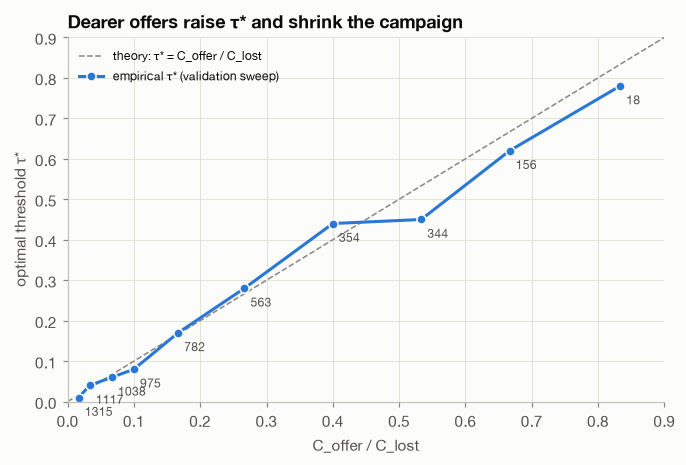

,C_offer,C_offer / C_lost,τ*,customers flagged,total cost
0,250,0.017,0.01,1315,343750.0
1,500,0.033,0.04,1117,648500.0
2,1000,0.067,0.06,1038,1188000.0
3,1500,0.100,0.08,975,1687500.0
4,2500,0.167,0.17,782,2540000.0
5,4000,0.267,0.28,563,3497000.0
6,6000,0.400,0.44,354,4344000.0
7,8000,0.533,0.45,344,5032000.0
8,10000,0.667,0.62,156,5415000.0
9,12500,0.833,0.78,18,5595000.0


In [9]:
rows = []
for c_offer in [250, 500, 1000, 1500, 2500, 4000, 6000, 8000, 10000, 12500]:
    p_ = CostParams(c_offer=c_offer, c_lost=config.C_LOST)
    b_ = find_optimal_threshold(sweep_thresholds(y_val, cal_prob, p_))
    rows.append({'C_offer': c_offer, 'C_offer / C_lost': c_offer / config.C_LOST, 'τ*': float(b_['threshold']),
                 'customers flagged': int(b_['n_flagged']), 'total cost': float(b_['total_cost'])})
sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(config.RESULTS_DIR / 'threshold_sensitivity.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4.3))
ratio = sensitivity['C_offer / C_lost']
ax.plot([0, 0.9], [0, 0.9], color=P.MUTED, linestyle='--', linewidth=1, label='theory: τ* = C_offer / C_lost')
ax.plot(ratio, sensitivity['τ*'], color=P.BLUE, marker='o', markersize=6, markeredgecolor=P.SURFACE,
        label='empirical τ* (validation sweep)')
for r_, t_, n_ in zip(ratio, sensitivity['τ*'], sensitivity['customers flagged']):
    ax.annotate(f'{n_}', (r_, t_), xytext=(4, -12), textcoords='offset points', fontsize=8, color=P.INK_SECONDARY)
ax.set(xlabel='C_offer / C_lost', ylabel='optimal threshold τ*', xlim=(0, 0.9), ylim=(0, 0.9),
       title='Dearer offers raise τ* and shrink the campaign')
ax.legend(fontsize=8)
P.save_figure(fig, config.PLOTS_DIR / 'threshold_sensitivity.png')
plt.show()
sensitivity.round(3)

Numbers next to the markers are how many of the 1,409 validation customers get an offer. As $C_{offer}/C_{lost}$ rises, the optimal threshold rises almost exactly along the theoretical line and the campaign shrinks to the highest-risk customers only — the calibrated probabilities make the textbook Bayes-decision rule work in practice.

## 6 · Save calibration + threshold for the inference API

In [10]:
f1_threshold, f1_value = find_f1_optimal_threshold(y_val, cal_prob)
cfg = config.update_model_config({
    'calibration': {**calibrator.to_dict(), 'fitted_on': 'validation',
                    'brier_raw': rel_raw['brier'], 'brier_calibrated': rel_cal['brier']},
    'threshold': {'optimal': tau_star, 'naive': config.NAIVE_THRESHOLD,
                  'theoretical': params.breakeven_probability,
                  'f1_optimal_val': f1_threshold, 'f1_at_f1_optimal_val': f1_value,
                  'val_total_cost_at_optimal': float(best['total_cost'])},
    'costs': {'c_offer': params.c_offer, 'c_lost': params.c_lost, 'currency': params.currency},
    'risk_tiers': {'high': config.HIGH_RISK_MIN, 'medium': config.MEDIUM_RISK_MIN},
})
print(f'Saved: calibration a={calibrator.a:.4f}, b={calibrator.b:.4f}; τ*={tau_star:.2f}; '
      f'F1-optimal reference threshold={f1_threshold:.2f} (val F1 {f1_value:.4f})')

Saved: calibration a=1.0121, b=-1.0878; τ*=0.08; F1-optimal reference threshold=0.33 (val F1 0.6265)
